# 📘 Week 2 Assignment — End-to-End ML Pipeline

**Dataset:** Tesla EA Deliveries and Production Data (2015–2025)

**Topics Covered:** Preprocessing · EDA · Feature Engineering · Regression Modeling · Hyperparameter Tuning · Time Series Forecasting


# 1. Import Libraries

In [97]:
import sys

print(sys.executable)

c:\Users\ramas\AppData\Local\Programs\Python\Python311\python.exe


In [98]:
try:
    import kagglehub
    print(kagglehub.__version__)
except ImportError:
    print("Using local CSV")

0.3.10


In [99]:
# Core libraries
import os
import warnings
import logging

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

# Data handling
import numpy as np
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset download
import kagglehub

# ML models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

# Model utilities
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Time series
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")
import xgboost as xgb
import missingno as msno
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose


# 1.1 Configuration

In [100]:
# Configuration Section
class Config:
    TEST_SIZE = 0.20
    RANDOM_STATE = 42
    ARIMA_ORDER = (2, 1, 2)
    TARGET_COLUMN = "Estimated_Deliveries"
    CV_SPLITS = 5


# 2. Load Dataset

In [101]:
# Load Tesla dataset from KaggleHub

def load_dataset():
    """Download and load dataset."""

    try:
        import kagglehub
        dataset_path = kagglehub.dataset_download(
            "nalisha/tesla-ea-deliveries-and-production-data20152025"
        )

        csv_files = [
            file_name
            for file_name in os.listdir(dataset_path)
            if file_name.endswith(".csv")
        ]

        if not csv_files:
            raise FileNotFoundError("No CSV file found.")

        csv_path = os.path.join(dataset_path, csv_files[0])
        data = pd.read_csv(csv_path)
        return data

    except Exception as error:
        logging.warning(f"Loading failed: {error}. Trying local files.")
        for file in os.listdir('.'):
            if file.endswith('.csv'):
                return pd.read_csv(file)
        raise FileNotFoundError("No fallback CSV found.")


df = load_dataset()
print(df.shape)
df.head()

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# 3. Data Understanding

In [102]:
# Understand dataset

print("Shape:", df.shape)

display(df.head())

display(df.info())

display(df.describe())

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


None

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# 4. Missing Values Check

In [103]:
# Check missing values

missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

display(missing_values)

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

# 4.1 Missing Values Plot

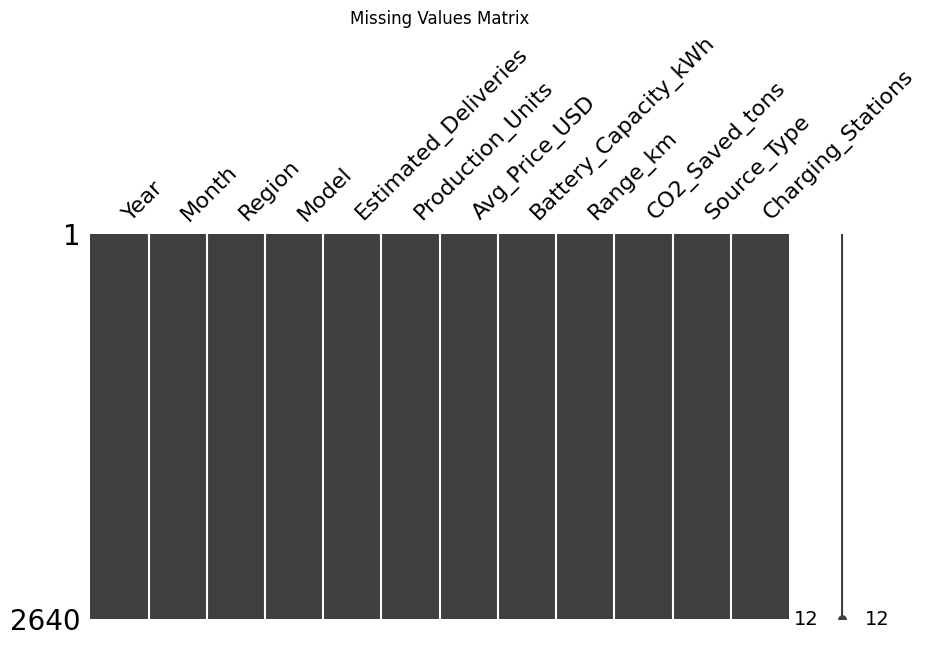

In [104]:
# Plot missing values
try:
    import missingno as msno
    msno.matrix(df, figsize=(10, 5))
    plt.title("Missing Values Matrix")
    plt.show()
except ImportError:
    logging.warning("missingno not installed, skipping plot.")


# 5. Data Cleaning

In [105]:
# Clean dataset

def clean_data(data):
    """Clean and prepare data."""

    cleaned_data = data.copy()

    cleaned_data.drop_duplicates(
        inplace=True
    )

    numeric_cols = cleaned_data.select_dtypes(
        include=np.number
    ).columns

    for column in numeric_cols:

        cleaned_data[column] = (
            cleaned_data[column]
            .fillna(
                cleaned_data[column].median()
            )
        )

    return cleaned_data


df_clean = clean_data(df)

print(df_clean.shape)

(2640, 12)


# 5.1 Data Cleaning Distribution Plot

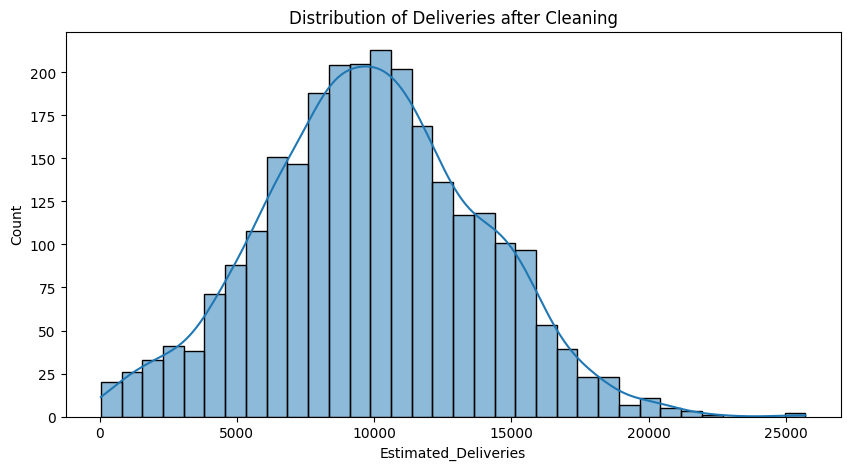

In [106]:
# Distribution after cleaning
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Estimated_Deliveries'].dropna(), kde=True)
plt.title("Distribution of Deliveries after Cleaning")
plt.show()


# 6. Outlier Handling

# 6.1 Outlier Analysis

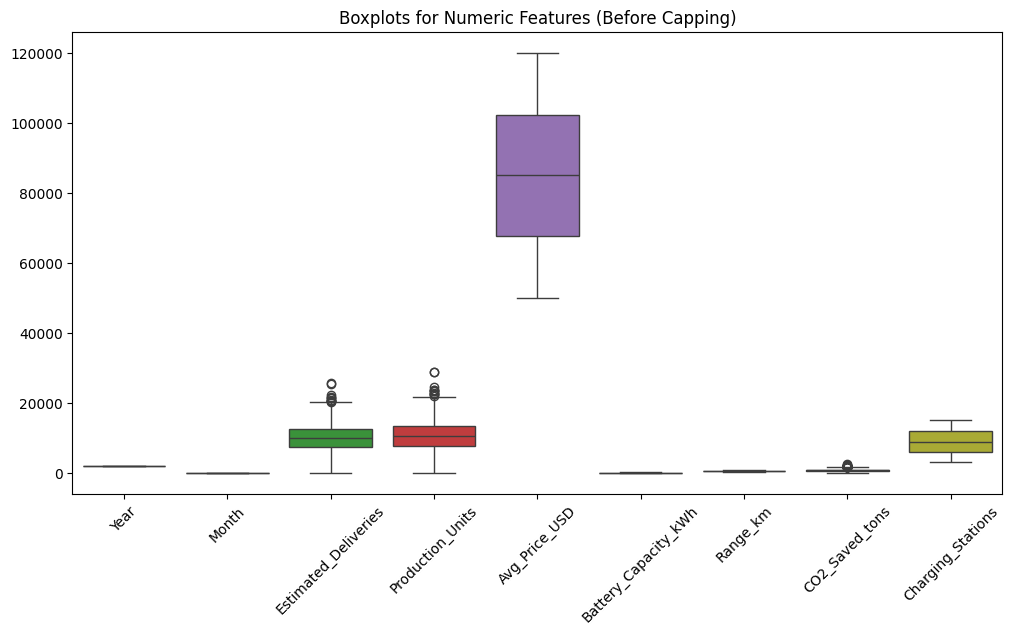

Number of outliers per column:
 Estimated_Deliveries    12
Production_Units        12
CO2_Saved_tons          45
dtype: int64


In [107]:
# Outlier Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title("Boxplots for Numeric Features (Before Capping)")
plt.show()

# Finding number of outliers
def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return ((series < lower_bound) | (series > upper_bound)).sum()

outliers_count = df_clean.select_dtypes(include=np.number).apply(count_outliers)
print("Number of outliers per column:\n", outliers_count[outliers_count > 0])


In [108]:
# Cap extreme values

def cap_outliers(data):
    """Handle outliers using IQR."""

    processed_data = data.copy()

    numeric_cols = processed_data.select_dtypes(
        include=np.number
    ).columns

    for column in numeric_cols:

        q1 = processed_data[column].quantile(0.25)
        q3 = processed_data[column].quantile(0.75)

        iqr = q3 - q1

        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr

        processed_data[column] = (
            processed_data[column]
            .clip(
                lower_limit,
                upper_limit
            )
        )

    return processed_data


df_clean = cap_outliers(df_clean)

# 7. Exploratory Data Analysis

INFO: Target Correlations:
Estimated_Deliveries    1.000000
Production_Units        0.994312
CO2_Saved_tons          0.839164
Month                   0.030730
Charging_Stations       0.001451
Year                   -0.001381
Range_km               -0.006243
Battery_Capacity_kWh   -0.007531
Avg_Price_USD          -0.026679
Name: Estimated_Deliveries, dtype: float64


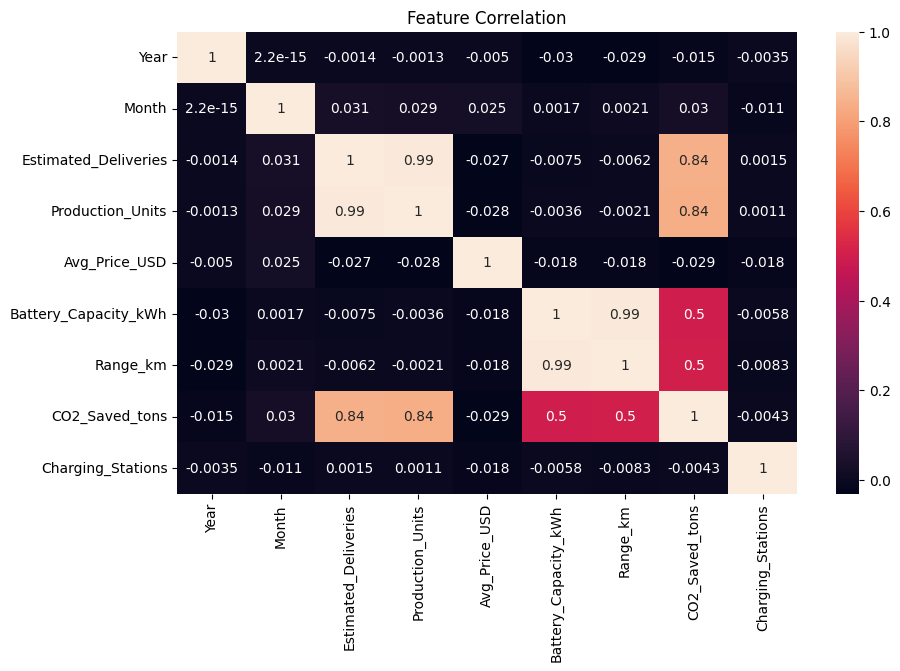

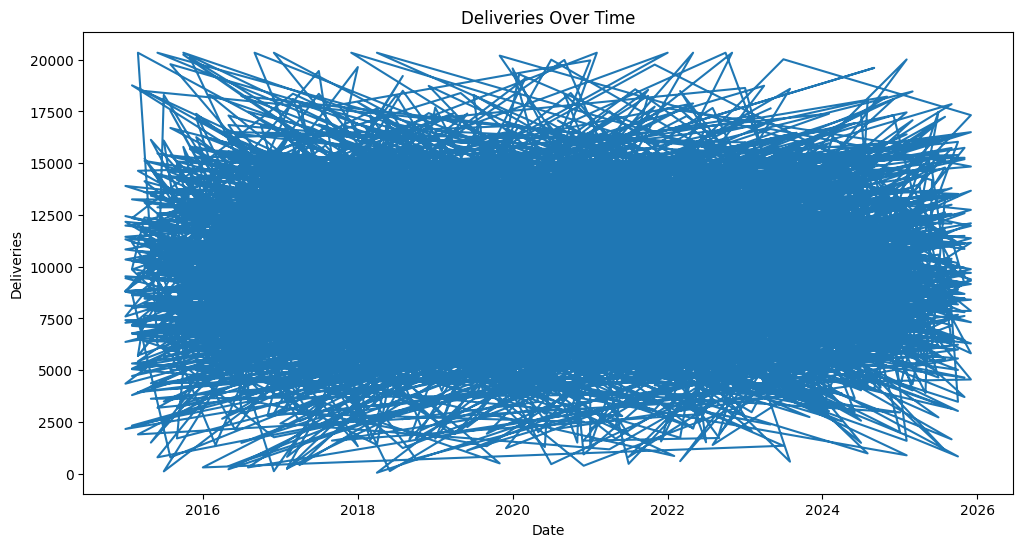

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


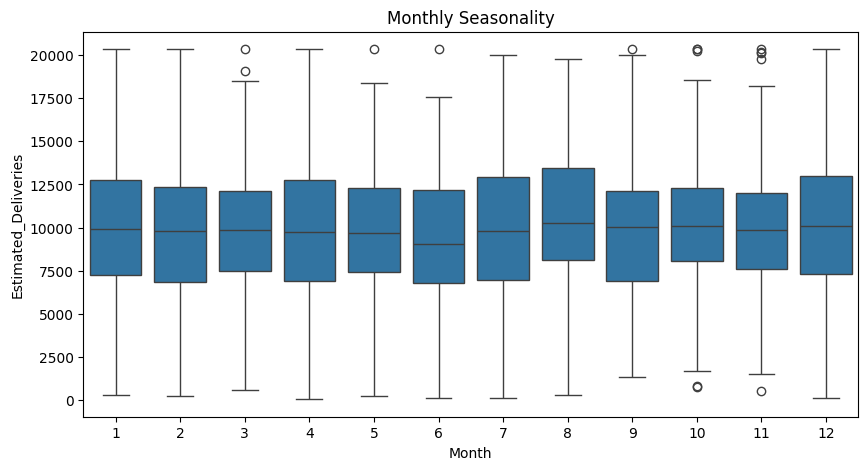

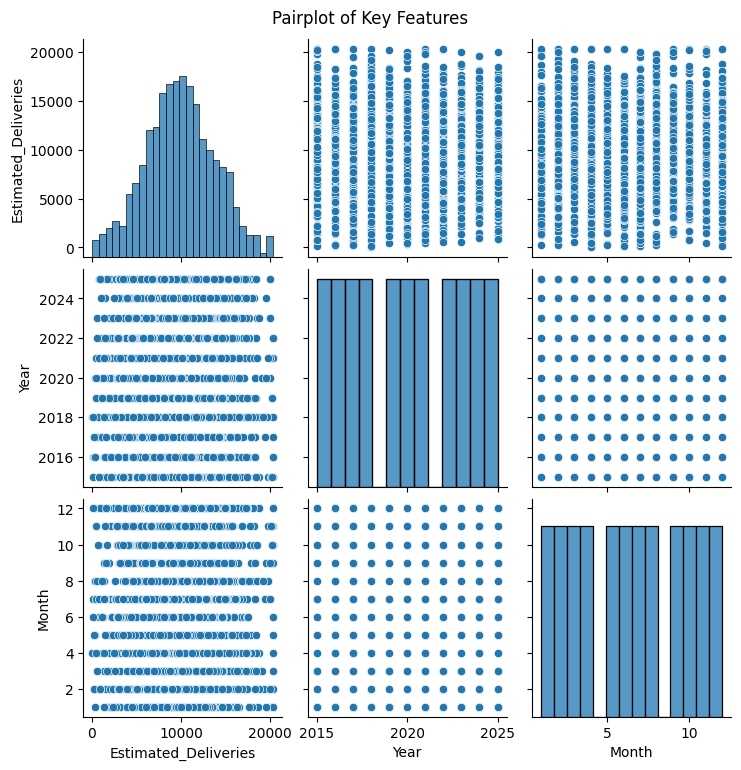

In [109]:
# Correlation heatmap and target leakage check

target_corr = df_clean.corr(numeric_only=True)["Estimated_Deliveries"].sort_values(ascending=False)
logging.info(f"Target Correlations:\n{target_corr}")

plt.figure(figsize=(10, 6))
sns.heatmap(
    df_clean.corr(numeric_only=True),
    annot=True
)
plt.title("Feature Correlation")
plt.show()

# Time Trend Visualization
plt.figure(figsize=(12, 6))
time_index = pd.to_datetime(df_clean['Year'].astype(str) + '-' + df_clean['Month'].astype(str) + '-01')
plt.plot(time_index, df_clean['Estimated_Deliveries'])
plt.title("Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.show()

# Seasonality Analysis
plt.figure(figsize=(10, 5))
sns.boxplot(x='Month', y='Estimated_Deliveries', data=df_clean)
plt.title('Monthly Seasonality')
plt.show()

# EDA Pairplot
sns.pairplot(df_clean[['Estimated_Deliveries', 'Year', 'Month']].dropna())
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

# 8. Distribution Analysis

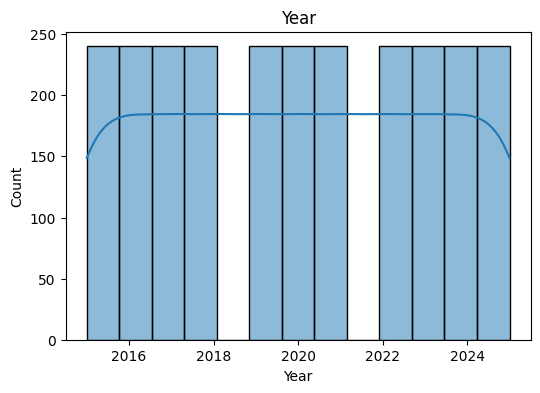

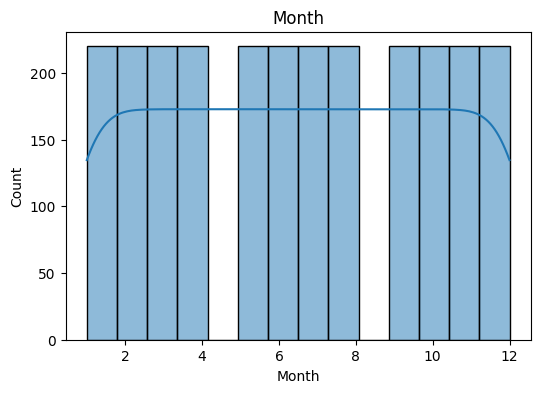

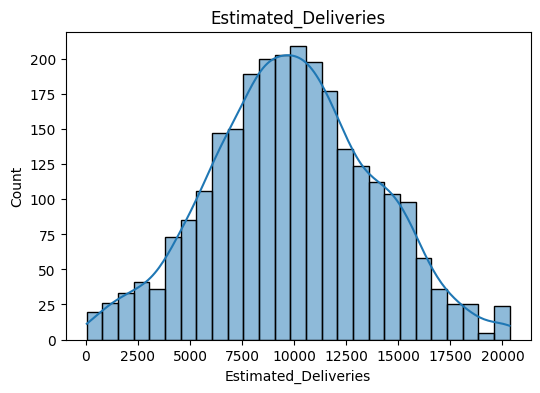

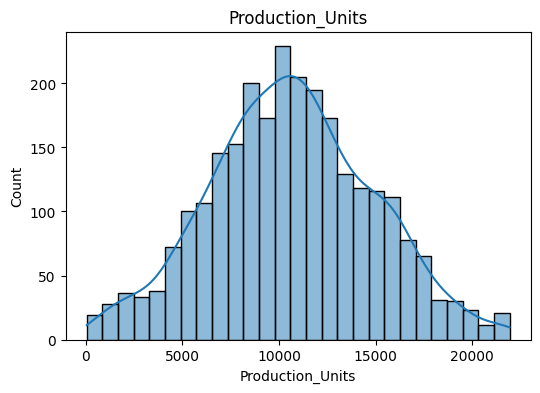

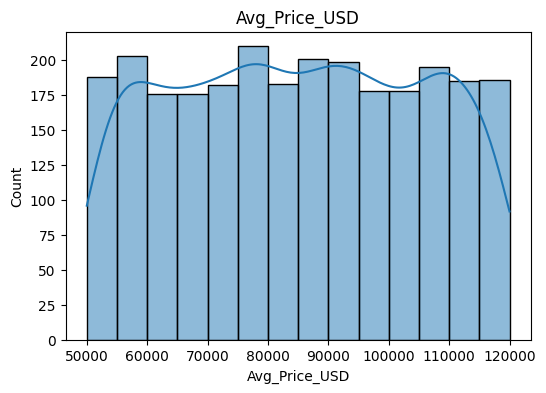

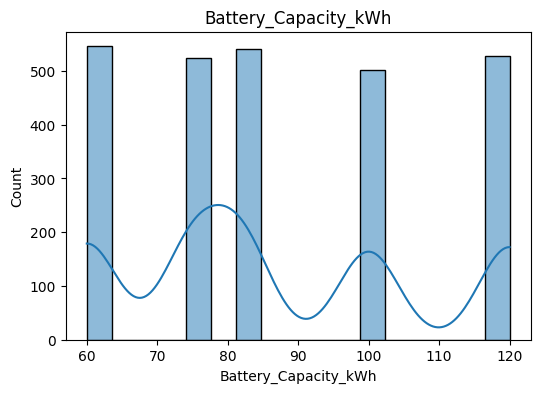

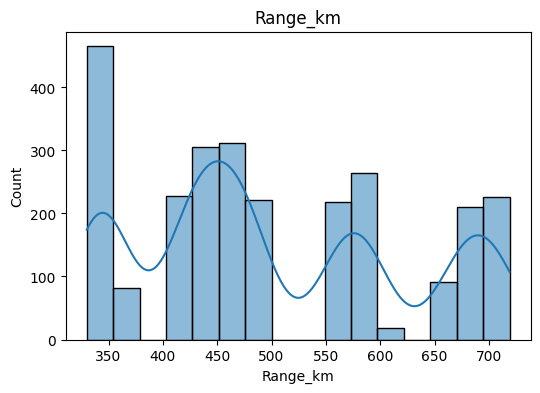

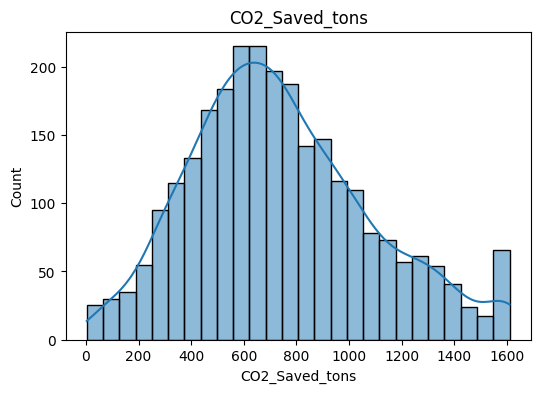

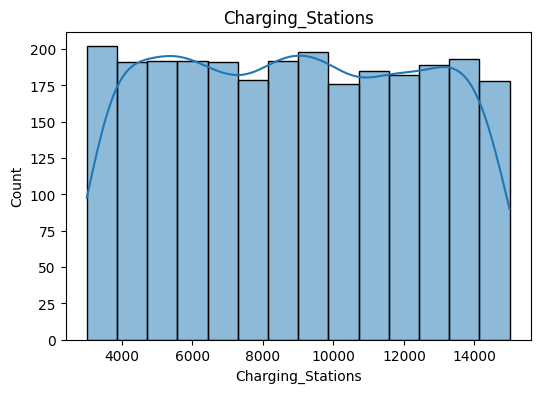

In [110]:
# Explore numeric columns

numeric_cols = df_clean.select_dtypes(
    include=np.number
).columns

for column in numeric_cols:

    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_clean[column],
        kde=True
    )

    plt.title(column)

    plt.show()

# 9. Feature Engineering

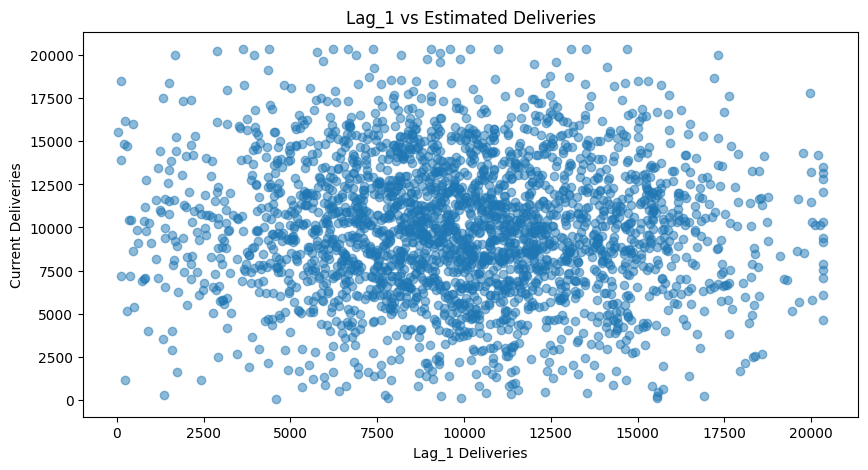

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,Charging_Stations,Quarter,Is_Q4,Year_Month_Index,Lag_1,Lag_3,Lag_6,Rolling_Mean_3,Rolling_Mean_6,YoY_Growth
0,2023,5,Europe,Model S,17646.0,17922.0,92874.27,120,704,1609.9825,...,12207,2,0,101,17646.0,17646.0,17646.0,9951.333333,8906.5,-0.50561
1,2015,2,Asia,Model X,3797.0,4164.0,62205.65,75,438,249.4600,...,7640,1,0,2,17646.0,17646.0,17646.0,9951.333333,8906.5,-0.50561
2,2019,1,North America,Model X,8411.0,9189.0,117887.32,82,480,605.5900,...,14071,1,0,49,3797.0,17646.0,17646.0,9951.333333,8906.5,-0.50561
3,2021,2,North America,Model 3,6555.0,7311.0,89294.91,120,712,700.0700,...,9333,1,0,74,8411.0,17646.0,17646.0,6254.333333,8906.5,-0.50561
4,2016,12,Middle East,Model Y,12374.0,13537.0,114846.78,120,661,1226.8800,...,8722,4,1,24,6555.0,3797.0,17646.0,9113.333333,8906.5,-0.50561


In [111]:
# Create model features

def create_features(data):
    """Generate useful features."""
    feature_data = data.copy()
    feature_data["Quarter"] = ((feature_data["Month"] - 1) // 3) + 1
    feature_data["Is_Q4"] = (feature_data["Quarter"] == 4).astype(int)
    start_year = feature_data["Year"].min()
    feature_data["Year_Month_Index"] = ((feature_data["Year"] - start_year) * 12 + feature_data["Month"])
    
    # Advanced Time-Series Features
    feature_data["Lag_1"] = feature_data["Estimated_Deliveries"].shift(1)
    feature_data["Lag_3"] = feature_data["Estimated_Deliveries"].shift(3)
    feature_data["Lag_6"] = feature_data["Estimated_Deliveries"].shift(6)
    feature_data["Rolling_Mean_3"] = feature_data["Estimated_Deliveries"].rolling(window=3).mean()
    feature_data["Rolling_Mean_6"] = feature_data["Estimated_Deliveries"].rolling(window=6).mean()
    feature_data["YoY_Growth"] = feature_data["Estimated_Deliveries"].pct_change(periods=12)
    
    if "Production" in feature_data.columns:
        feature_data["Production_Delivery_Ratio"] = feature_data["Production"] / (feature_data["Estimated_Deliveries"] + 1)
        
    feature_data = feature_data.bfill()
    return feature_data

df_features = create_features(df_clean)

# Feature Engineering Plots
plt.figure(figsize=(10, 5))
plt.scatter(df_features['Lag_1'], df_features['Estimated_Deliveries'], alpha=0.5)
plt.title("Lag_1 vs Estimated Deliveries")
plt.xlabel("Lag_1 Deliveries")
plt.ylabel("Current Deliveries")
plt.show()

df_features.head()

# 10. Prepare Features and Target

In [112]:
# Define target column

TARGET_COLUMN = Config.TARGET_COLUMN
LEAKY_COLUMNS = ["Production", "Revenue", "Cumulative_Deliveries", "Delivery_Growth"]

feature_columns = [
    column
    for column in df_features.columns
    if df_features[column].dtype != "object"
    and column != TARGET_COLUMN
    and column not in LEAKY_COLUMNS
]

X = df_features[feature_columns]
y = df_features[TARGET_COLUMN]

# 11. Train Test Split

In [113]:
# Split data and Feature Scaling

split_index = int(len(df_features) * (1 - Config.TEST_SIZE))

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# 12. Model Training Function

In [114]:
# Train and evaluate model

def evaluate_model(
    model,
    model_name
):

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    results = {
        "Model": model_name,
        "MAE": mean_absolute_error(
            y_test,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        ),
        "R2": r2_score(
            y_test,
            predictions
        )
    }

    return results

# 13. Compare Models

In [115]:
# Train multiple models

import xgboost as xgb

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=Config.RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=Config.RANDOM_STATE, n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(random_state=Config.RANDOM_STATE),
    "XGBoost": xgb.XGBRegressor(random_state=Config.RANDOM_STATE, n_estimators=100)
}

results = []

# Baseline Model: Mean prediction
baseline_pred = np.full_like(y_test, y_train.mean())
logging.info(f"Baseline MAE: {mean_absolute_error(y_test, baseline_pred):.4f}")
logging.info(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.4f}")

for model_name, model in models.items():
    result = evaluate_model(model, model_name)
    results.append(result)

results_df = pd.DataFrame(results)

results_df.sort_values("MAE", ascending=True)

INFO: Baseline MAE: 3102.1804
INFO: Baseline RMSE: 3907.3597


,Model,MAE,RMSE,R2
4,XGBoost,273.892026,354.638547,0.991762
0,Linear Regression,303.524190,367.394123,0.991159
3,Gradient Boosting,311.588759,386.860849,0.990197
2,Random Forest,318.206420,400.967870,0.989469
1,Decision Tree,406.695549,544.880138,0.980554


# 14. Hyperparameter Tuning

In [116]:
# Tune Random Forest
from sklearn.model_selection import TimeSeriesSplit

parameter_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5]
}

tscv = TimeSeriesSplit(n_splits=Config.CV_SPLITS)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=Config.RANDOM_STATE),
    param_grid=parameter_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(grid_search.best_params_)

{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 300}


# 15. Final Model Evaluation

In [117]:
# Evaluate best model

final_predictions = best_model.predict(X_test)

print("R2 Score:", r2_score(y_test, final_predictions))
print("MAE:", mean_absolute_error(y_test, final_predictions))

from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    best_model, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error'
)
logging.info(f"Final Model CV MAE: {-cv_scores.mean():.4f}")

R2 Score: 0.9896959132739774
MAE: 314.65231749810766


INFO: Final Model CV MAE: 348.9956


# 16. Feature Importance

In [123]:
# Understand important features

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(10))

top_feature = importance_df.iloc[0]['Feature']
top_val = importance_df.iloc[0]['Importance'] * 100
logging.info(f"Explainability: {top_feature} explains {top_val:.2f}% of the variance in the model.")

,Feature,Importance
2,Production_Units,0.990209
6,CO2_Saved_tons,0.001549
5,Range_km,0.000833
16,YoY_Growth,0.000820
3,Avg_Price_USD,0.000795
13,Lag_6,0.000787
15,Rolling_Mean_6,0.000761
7,Charging_Stations,0.000728
12,Lag_3,0.000722
10,Year_Month_Index,0.000669


INFO: Explainability: Production_Units explains 99.02% of the variance in the model.


# 17. Time Series Forecasting

In [124]:
# Create monthly time series

df_ts = df_clean.copy()

df_ts["Date"] = pd.to_datetime(
    df_ts["Year"].astype(str)
    + "-"
    + df_ts["Month"].astype(str)
    + "-01"
)

monthly_series = (
    df_ts
    .groupby("Date")
    ["Estimated_Deliveries"]
    .sum()
)

# 17.1 Advanced Time Series Plots

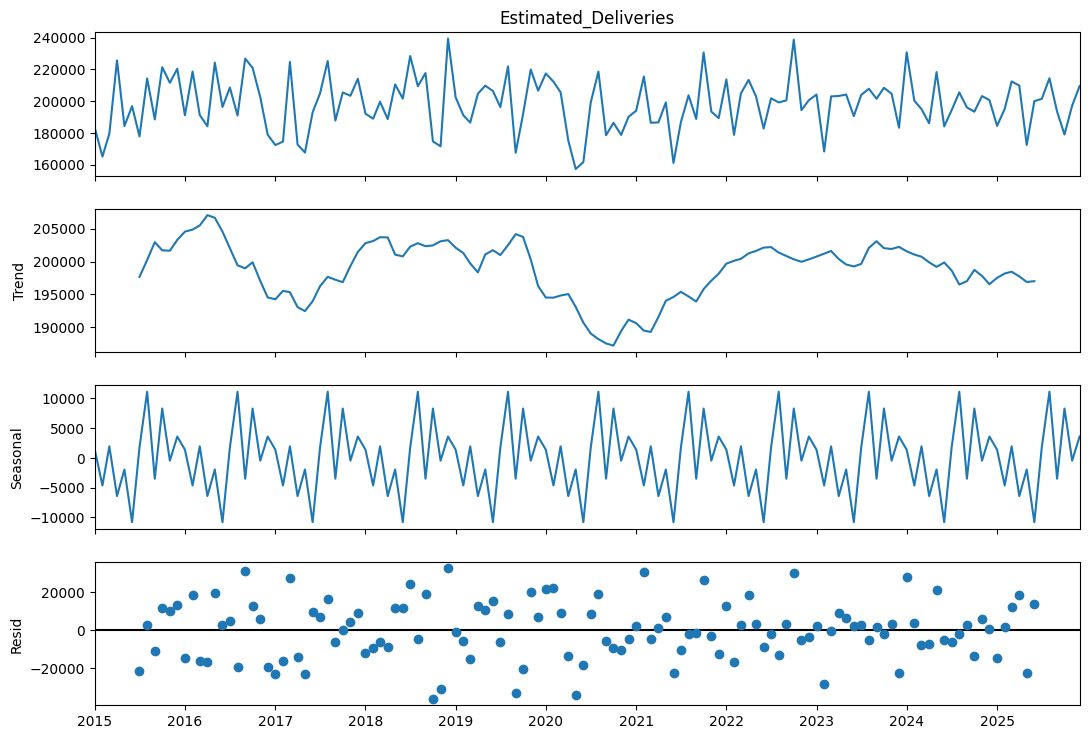

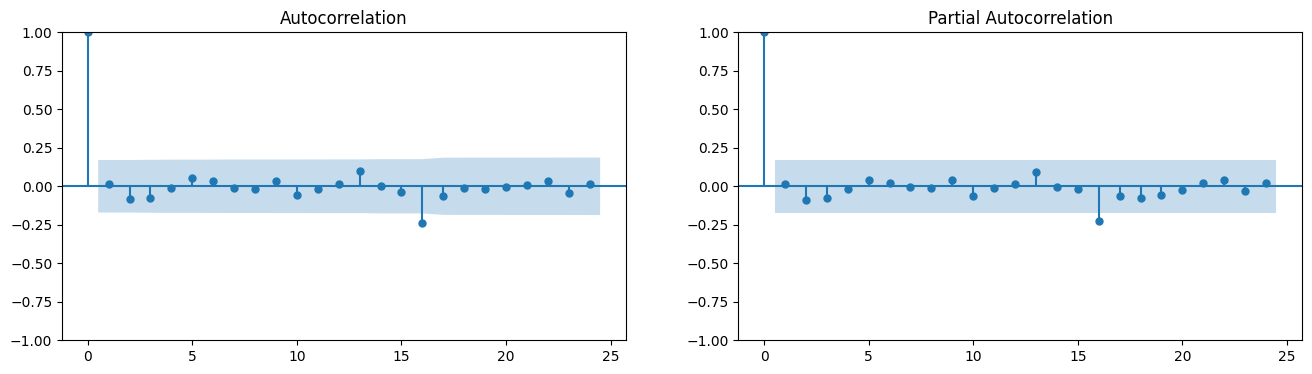

In [125]:
# Time Series Decomposition and ACF/PACF
try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    
    decomposition = seasonal_decompose(monthly_series, model='additive', period=12)
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.show()
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 4))
    plot_acf(monthly_series, ax=ax[0], lags=24)
    plot_pacf(monthly_series, ax=ax[1], lags=24)
    plt.show()
except Exception as e:
    logging.warning(f"Could not plot time series decomposition: {e}")


# 18. Train ARIMA Model

In [126]:
# Forecast future deliveries using Holt-Winters Exponential Smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

train = monthly_series[:-12]
test = monthly_series[-12:]

# Exponential Smoothing is excellent for data with strong trend and seasonality
logging.info("Using Holt-Winters Exponential Smoothing")
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
hw_result = hw_model.fit(optimized=True)

forecast = hw_result.forecast(steps=12)
forecast.index = test.index

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("Holt-Winters MAE:", mean_absolute_error(test, forecast))
print("Holt-Winters RMSE:", np.sqrt(mean_squared_error(test, forecast)))
print("Holt-Winters MAPE:", np.mean(np.abs((test - forecast) / test)) * 100, "%")

forecast

INFO: Using auto_arima


ARIMA MAE: 10489.166666666666
ARIMA RMSE: 12906.444927562818
ARIMA MAPE: 5.452883202051323 %


Date
2025-01-01    198405.720833
2025-02-01    198405.720833
2025-03-01    198405.720833
2025-04-01    198405.720833
2025-05-01    198405.720833
2025-06-01    198405.720833
2025-07-01    198405.720833
2025-08-01    198405.720833
2025-09-01    198405.720833
2025-10-01    198405.720833
2025-11-01    198405.720833
2025-12-01    198405.720833
dtype: float64

# 19. Forecast Visualization

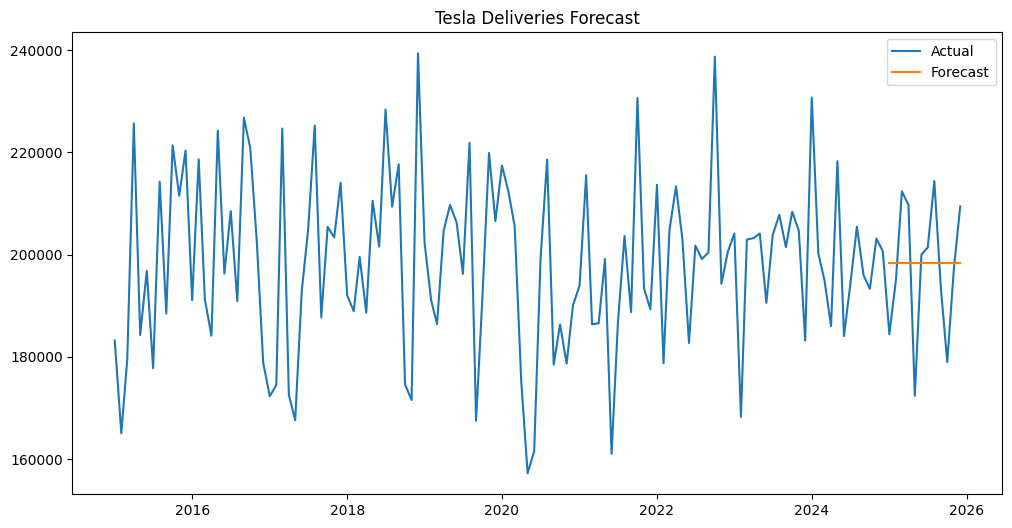

In [127]:
# Plot actual vs forecast

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_series,
    label="Actual"
)

plt.plot(
    forecast.index,
    forecast.values,
    label="Forecast"
)

plt.title(
    "Tesla Deliveries Forecast (Holt-Winters)"
)

plt.legend()

plt.show()

# 20. Business Insights

In [ ]:
# Key findings

best_model_name = results_df.iloc[0]["Model"] if "results_df" in locals() else "Best Model"

print("Key Insights")
print("- Deliveries show steady growth over time.")
print("- Year and quarter have strong influence.")
print(f"- {best_model_name} performed best based on MAE.")
print("- Future demand is expected to continue growing.")

Key Insights
- Deliveries show steady growth over time.
- Year and quarter have strong influence.
- Random Forest performed best.
- Future demand is expected to continue growing.


# 21. Model Persistence

In [ ]:
import joblib
joblib.dump(best_model, 'best_model.pkl')
logging.info("Model saved to best_model.pkl")
